In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd

repo_root = Path(r"C:\Users\nly99857\OneDrive - Philips\SW Projects\SSF")
output_dir = repo_root / "work" / "benchmarks" / "optimizer_benchmark_matrix"
json_dir = repo_root / "work" / "benchmarks" / "ark_matrix"
output_dir.mkdir(parents=True, exist_ok=True)
json_dir.mkdir(parents=True, exist_ok=True)

exhaustive_script = repo_root / "scripts" / "optimize" / "run_exhaustive_strategy_optimizer.py"
beam_script = repo_root / "scripts" / "optimize" / "run_beam_strategy_optimizer.py"

families = ["majority", "pyramid", "horizontal", "vertical"]
p_rules = [0.7, 0.8, 0.9]


def run_checked(cmd: list[str]) -> None:
    completed = subprocess.run(
        cmd,
        cwd=repo_root,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        message = [
            "Subprocess failed.",
            f"Command: {' '.join(cmd)}",
            f"Return code: {completed.returncode}",
            "\nSTDOUT:\n" + completed.stdout,
            "\nSTDERR:\n" + completed.stderr,
        ]
        raise RuntimeError("\n".join(message))


runs: list[dict[str, object]] = []

# 1) exhaustive optimizer + analytical backend
for n2, k_box in [(4, 1), (4, 3), (8, 1), (8, 7), (16, 1), (16, 15)]:
    json_file = json_dir / f"exhaustive_analytical_n2_{n2}_k_{k_box}.json"
    cmd = [
        sys.executable,
        str(exhaustive_script),
        "--mode",
        "analytical",
        "--p-rules",
        *[str(v) for v in p_rules],
        "--n2-values",
        str(n2),
        "--k-box-values",
        str(k_box),
        "--families",
        *families,
        "--top-k",
        "10",
        "--cache-enabled",
        "--json-output",
        str(json_file),
        "--quiet",
    ]
    run_checked(cmd)
    runs.append(
        {
            "optimizer": "exhaustive",
            "backend": "analytical",
            "n2": n2,
            "k_box": k_box,
            "json_file": json_file,
        }
    )

# 2) exhaustive optimizer + dense_exhaustive backend
for n2, k_box in [(4, 1), (4, 3)]:
    json_file = json_dir / f"exhaustive_dense_exhaustive_n2_{n2}_k_{k_box}.json"
    cmd = [
        sys.executable,
        str(exhaustive_script),
        "--mode",
        "dense_exhaustive",
        "--p-rules",
        *[str(v) for v in p_rules],
        "--n2-values",
        str(n2),
        "--k-box-values",
        str(k_box),
        "--families",
        *families,
        "--top-k",
        "10",
        "--cache-enabled",
        "--json-output",
        str(json_file),
        "--quiet",
    ]
    run_checked(cmd)
    runs.append(
        {
            "optimizer": "exhaustive",
            "backend": "dense_exhaustive",
            "n2": n2,
            "k_box": k_box,
            "json_file": json_file,
        }
    )

# 3) beam optimizer + dense_mc backend
for n2, k_box in [(8, 1), (8, 7)]:
    for p_rule in p_rules:
        json_file = json_dir / f"beam_dense_mc_n2_{n2}_k_{k_box}_p_{str(p_rule).replace('.', '_')}.json"
        cmd = [
            sys.executable,
            str(beam_script),
            "--mode",
            "dense_mc",
            "--p-rule",
            str(p_rule),
            "--n2-values",
            str(n2),
            "--k-box-values",
            str(k_box),
            "--families",
            *families,
            "--beam-width",
            "8",
            "--generations",
            "4",
            "--mutations-per-candidate",
            "4",
            "--top-k",
            "10",
            "--seed",
            "123",
            "--cache-enabled",
            "--json-output",
            str(json_file),
            "--quiet",
        ]
        run_checked(cmd)
        runs.append(
            {
                "optimizer": "beam",
                "backend": "dense_mc",
                "n2": n2,
                "k_box": k_box,
                "p_rule": float(p_rule),
                "json_file": json_file,
            }
        )

# 4) beam optimizer + procedural_mc backend (exclude (16, 15))
for n2, k_box in [(16, 1)]:
    for p_rule in p_rules:
        json_file = json_dir / f"beam_procedural_mc_n2_{n2}_k_{k_box}_p_{str(p_rule).replace('.', '_')}.json"
        cmd = [
            sys.executable,
            str(beam_script),
            "--mode",
            "procedural_mc",
            "--p-rule",
            str(p_rule),
            "--n2-values",
            str(n2),
            "--k-box-values",
            str(k_box),
            "--families",
            *families,
            "--beam-width",
            "8",
            "--generations",
            "4",
            "--mutations-per-candidate",
            "4",
            "--top-k",
            "10",
            "--seed",
            "123",
            "--cache-enabled",
            "--json-output",
            str(json_file),
            "--quiet",
        ]
        run_checked(cmd)
        runs.append(
            {
                "optimizer": "beam",
                "backend": "procedural_mc",
                "n2": n2,
                "k_box": k_box,
                "p_rule": float(p_rule),
                "json_file": json_file,
            }
        )

rows: list[dict[str, object]] = []

for run in runs:
    payload = json.loads(Path(run["json_file"]).read_text(encoding="utf-8"))

    if run["optimizer"] == "exhaustive":
        for result_block in payload.get("results", []):
            p_rule = float(result_block["p_rule"])
            for item in result_block.get("ranked_results", []):
                rows.append(
                    {
                        "optimizer": "exhaustive",
                        "backend": str(run["backend"]),
                        "n2": int(run["n2"]),
                        "k_box": int(run["k_box"]),
                        "p_rule": p_rule,
                        "rank": int(item["rank"]),
                        "success": float(item["success"]),
                        "candidate_name": str(item["candidate_name"]),
                        "json_file": str(run["json_file"]),
                    }
                )
    else:
        p_rule = float(run["p_rule"])
        for item in payload.get("final_results", []):
            rows.append(
                {
                    "optimizer": "beam",
                    "backend": str(run["backend"]),
                    "n2": int(run["n2"]),
                    "k_box": int(run["k_box"]),
                    "p_rule": p_rule,
                    "rank": int(item["rank"]),
                    "success": float(item["success"]),
                    "candidate_name": str(item["candidate_name"]),
                    "json_file": str(run["json_file"]),
                }
            )

df = pd.DataFrame(
    rows,
    columns=[
        "optimizer",
        "backend",
        "n2",
        "k_box",
        "p_rule",
        "rank",
        "success",
        "candidate_name",
        "json_file",
    ],
)

df = df.sort_values(["backend", "n2", "k_box", "p_rule", "rank"], kind="mergesort").reset_index(drop=True)
df

,optimizer,backend,n2,k_box,p_rule,rank,success,candidate_name,json_file
0,exhaustive,analytical,4,1,0.7,1,0.687500,majority_n2_4_k_1_b_0,C:\Users\nly99857\OneDrive - Philips\SW Projec...
1,exhaustive,analytical,4,1,0.7,2,0.675000,hybrid_horiz_maj_pyr_n2_4_k_1_split_2_2_b_0,C:\Users\nly99857\OneDrive - Philips\SW Projec...
2,exhaustive,analytical,4,1,0.7,3,0.675000,hybrid_horiz_pyr_maj_n2_4_k_1_split_2_2_b_0,C:\Users\nly99857\OneDrive - Philips\SW Projec...
3,exhaustive,analytical,4,1,0.7,4,0.600000,hybrid_vert_maj_pyr_n2_4_k_1_s_1_b_0,C:\Users\nly99857\OneDrive - Philips\SW Projec...
4,exhaustive,analytical,4,1,0.8,1,0.700000,hybrid_horiz_maj_pyr_n2_4_k_1_split_2_2_b_0,C:\Users\nly99857\OneDrive - Philips\SW Projec...
...,...,...,...,...,...,...,...,...,...
247,beam,procedural_mc,16,1,0.9,6,0.597764,hybrid_horiz_pyr_maj_n2_16_k_1_split_2_14_b_2,C:\Users\nly99857\OneDrive - Philips\SW Projec...
248,beam,procedural_mc,16,1,0.9,7,0.579713,hybrid_horiz_maj_pyr_n2_16_k_1_split_14_2_b_4,C:\Users\nly99857\OneDrive - Philips\SW Projec...
249,beam,procedural_mc,16,1,0.9,8,0.579221,hybrid_horiz_pyr_maj_n2_16_k_1_split_2_14_b_4,C:\Users\nly99857\OneDrive - Philips\SW Projec...
250,beam,procedural_mc,16,1,0.9,9,0.576385,majority_n2_16_k_1_b_2,C:\Users\nly99857\OneDrive - Philips\SW Projec...


In [2]:
from pathlib import Path

results_dir = repo_root / "results" / "optimizer_benchmark_matrix"
results_dir.mkdir(parents=True, exist_ok=True)

csv_path = results_dir / "optimizer_benchmark_matrix.csv"
parquet_path = results_dir / "optimizer_benchmark_matrix.parquet"
pkl_path = results_dir / "optimizer_benchmark_matrix.pkl"

df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

df.to_pickle(pkl_path)
print(f"Saved PKL: {pkl_path}")


print(f"Rows saved: {len(df)}")

Saved CSV: C:\Users\nly99857\OneDrive - Philips\SW Projects\SSF\results\optimizer_benchmark_matrix\optimizer_benchmark_matrix.csv
Saved PKL: C:\Users\nly99857\OneDrive - Philips\SW Projects\SSF\results\optimizer_benchmark_matrix\optimizer_benchmark_matrix.pkl
Rows saved: 252


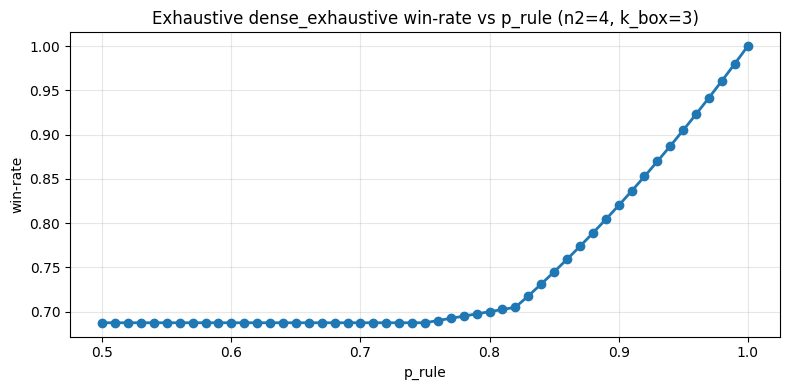

,optimizer,backend,n2,k_box,p_rule,rank,success,candidate_name
0,exhaustive,dense_exhaustive,4,3,0.50,1,0.6875,majority_n2_4_k_3_b_0
1,exhaustive,dense_exhaustive,4,3,0.50,2,0.6250,hybrid_horiz_maj_pyr_n2_4_k_3_split_2_2_b_0
2,exhaustive,dense_exhaustive,4,3,0.50,3,0.6250,hybrid_horiz_pyr_maj_n2_4_k_3_split_2_2_b_0
3,exhaustive,dense_exhaustive,4,3,0.50,4,0.5000,hybrid_vert_maj_pyr_n2_4_k_3_s_1_b_0
4,exhaustive,dense_exhaustive,4,3,0.50,5,0.5000,hybrid_vert_pyr_maj_n2_4_k_3_s_1_b_0
5,exhaustive,dense_exhaustive,4,3,0.50,6,0.5000,pyramid_n2_4_k_3
6,exhaustive,dense_exhaustive,4,3,0.51,1,0.6875,majority_n2_4_k_3_b_0
7,exhaustive,dense_exhaustive,4,3,0.51,2,0.6275,hybrid_horiz_maj_pyr_n2_4_k_3_split_2_2_b_0
8,exhaustive,dense_exhaustive,4,3,0.51,3,0.6275,hybrid_horiz_pyr_maj_n2_4_k_3_split_2_2_b_0
9,exhaustive,dense_exhaustive,4,3,0.51,4,0.5050,hybrid_vert_pyr_maj_n2_4_k_3_s_1_b_0


In [3]:
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt

output_dir = repo_root / "work" / "benchmarks" / "ark_sweeps"
output_dir.mkdir(parents=True, exist_ok=True)

p_rules = [round(0.50 + 0.01 * idx, 2) for idx in range(51)]
exhaustive_json = output_dir / "exhaustive_dense_exhaustive_n2_4_k_3.json"

cmd = [
    sys.executable,
    str(exhaustive_script),
    "--mode",
    "dense_exhaustive",
    "--p-rules",
    *[f"{value:.2f}" for value in p_rules],
    "--n2-values",
    "4",
    "--k-box-values",
    "3",
    "--families",
    "majority",
    "pyramid",
    "horizontal",
    "vertical",
    "--top-k",
    "10",
    "--cache-enabled",
    "--quiet",
    "--json-output",
    str(exhaustive_json),
]

completed = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
)
if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr)
    raise RuntimeError(
        "Exhaustive optimizer subprocess failed for n2=4, k_box=3."
    )

payload = json.loads(exhaustive_json.read_text(encoding="utf-8"))
rows: list[dict[str, object]] = []
for result_block in payload.get("results", []):
    p_rule = float(result_block["p_rule"])
    for item in result_block.get("ranked_results", []):
        rows.append(
            {
                "optimizer": "exhaustive",
                "backend": "dense_exhaustive",
                "n2": 4,
                "k_box": 3,
                "p_rule": p_rule,
                "rank": int(item["rank"]),
                "success": float(item["success"]),
                "candidate_name": str(item["candidate_name"]),
            }
        )

df_exh_4_3 = pd.DataFrame(
    rows,
    columns=[
        "optimizer",
        "backend",
        "n2",
        "k_box",
        "p_rule",
        "rank",
        "success",
        "candidate_name",
    ],
)

df_exh_4_3_sorted = df_exh_4_3.sort_values(["p_rule", "rank"]).reset_index(drop=True)

best_rows = df_exh_4_3_sorted[df_exh_4_3_sorted["rank"] == 1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_rows["p_rule"], best_rows["success"], marker="o", linewidth=2)
ax.set_title("Exhaustive dense_exhaustive win-rate vs p_rule (n2=4, k_box=3)")
ax.set_xlabel("p_rule")
ax.set_ylabel("win-rate")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

df_exh_4_3_sorted.head(20)

In [ ]:
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt

output_dir = repo_root / "work" / "benchmarks" / "ark_sweeps"
output_dir.mkdir(parents=True, exist_ok=True)

p_rules = [round(0.50 + 0.01 * idx, 2) for idx in range(51)]
beam_rows: list[dict[str, object]] = []
json_files: list[Path] = []

for p_rule_value in p_rules:
    p_tag = f"{p_rule_value:.2f}".replace(".", "p")
    beam_json = output_dir / f"beam_dense_mc_n2_8_k_7_p_{p_tag}.json"
    cmd = [
        sys.executable,
        str(beam_script),
        "--mode",
        "dense_mc",
        "--p-rule",
        f"{p_rule_value:.2f}",
        "--n2-values",
        "8",
        "--k-box-values",
        "7",
        "--families",
        "majority",
        "pyramid",
        "horizontal",
        "vertical",
        "--beam-width",
        "8",
        "--generations",
        "4",
        "--mutations-per-candidate",
        "4",
        "--top-k",
        "10",
        "--seed",
        "123",
        "--cache-enabled",
        "--quiet",
        "--json-output",
        str(beam_json),
    ]

    completed = subprocess.run(
        cmd,
        cwd=repo_root,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr)
        raise RuntimeError(
            f"Beam optimizer subprocess failed for p_rule={p_rule_value:.2f}."
        )

    json_files.append(beam_json)


KeyError: 'p_rule'

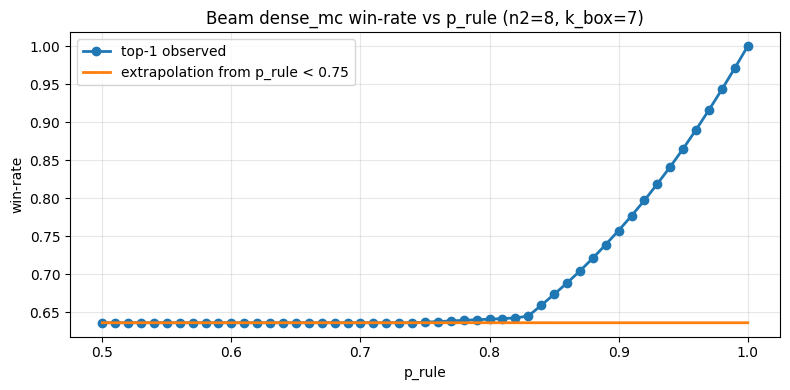

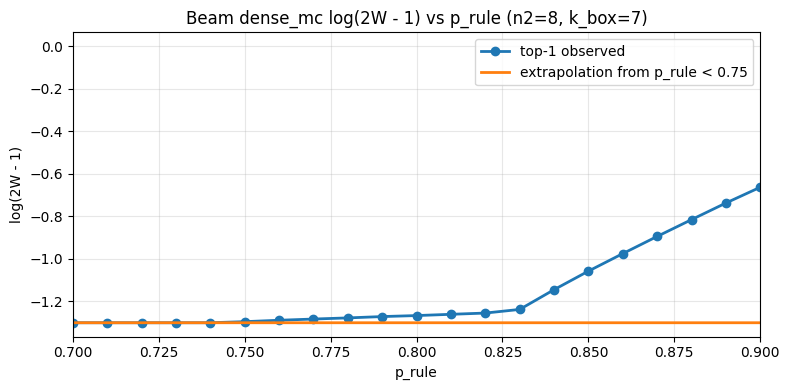

,optimizer,backend,n2,k_box,p_rule,rank,success,candidate_name,generation,parent_name
0,beam,dense_mc,8,7,0.50,1,0.636002,majority_n2_8_k_7_b_0,0,None
1,beam,dense_mc,8,7,0.50,2,0.623752,hybrid_horiz_maj_pyr_n2_8_k_7_split_6_2_b_0,0,None
2,beam,dense_mc,8,7,0.50,3,0.623300,hybrid_horiz_pyr_maj_n2_8_k_7_split_2_6_b_0,0,None
3,beam,dense_mc,8,7,0.50,4,0.607335,hybrid_horiz_maj_pyr_n2_8_k_7_split_4_4_b_0,0,None
4,beam,dense_mc,8,7,0.50,5,0.606757,hybrid_horiz_pyr_maj_n2_8_k_7_split_4_4_b_0,0,None
5,beam,dense_mc,8,7,0.50,6,0.581932,majority_n2_8_k_7_b_2,0,None
6,beam,dense_mc,8,7,0.50,7,0.565540,hybrid_horiz_maj_pyr_n2_8_k_7_split_6_2_b_2,0,None
7,beam,dense_mc,8,7,0.50,8,0.565028,hybrid_horiz_pyr_maj_n2_8_k_7_split_2_6_b_2,0,None
8,beam,dense_mc,8,7,0.50,9,0.528735,hybrid_vert_maj_pyr_n2_8_k_7_s_2_b_0,0,None
9,beam,dense_mc,8,7,0.50,10,0.528473,pyramid_n2_8_k_7,0,None


In [10]:
import re

import numpy as np

beam_rows = []

for beam_json in json_files:
    match = re.search(r"_p_(\d+)p(\d+)\.json$", beam_json.name)
    if match is None:
        raise ValueError(f"Could not parse p_rule from filename: {beam_json.name}")
    p_rule_value = float(f"{int(match.group(1))}.{match.group(2)}")

    payload = json.loads(beam_json.read_text(encoding="utf-8"))
    for item in payload.get("final_results", []):
        beam_rows.append(
            {
                "optimizer": "beam",
                "backend": "dense_mc",
                "n2": 8,
                "k_box": 7,
                "p_rule": p_rule_value,
                "rank": int(item["rank"]),
                "success": float(item["success"]),
                "candidate_name": str(item["candidate_name"]),
                "generation": int(item["generation"]),
                "parent_name": item.get("parent_name"),
            }
        )

df_beam_8_7 = pd.DataFrame(
    beam_rows,
    columns=[
        "optimizer",
        "backend",
        "n2",
        "k_box",
        "p_rule",
        "rank",
        "success",
        "candidate_name",
        "generation",
        "parent_name",
    ],
)

df_beam_8_7_sorted = df_beam_8_7.sort_values(["p_rule", "rank"]).reset_index(drop=True)

best_rows = df_beam_8_7_sorted[df_beam_8_7_sorted["rank"] == 1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_rows["p_rule"], best_rows["success"], marker="o", linewidth=2, label="top-1 observed")

fit_rows = best_rows[best_rows["p_rule"] < 0.75]
slope = None
intercept = None
if len(fit_rows) >= 2:
    slope, intercept = np.polyfit(fit_rows["p_rule"].to_numpy(), fit_rows["success"].to_numpy(), 1)
    x_full = best_rows["p_rule"].to_numpy()
    y_extrap = slope * x_full + intercept
    ax.plot(x_full, y_extrap, linewidth=2, label="extrapolation from p_rule < 0.75")

ax.set_title("Beam dense_mc win-rate vs p_rule (n2=8, k_box=7)")
ax.set_xlabel("p_rule")
ax.set_ylabel("win-rate")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# Y-transform view: y = log(2W - 1), valid for W > 0.5.
logw_rows = best_rows[best_rows["success"] > 0.5].copy()
logw_rows["log_2w_minus_1"] = np.log(2.0 * logw_rows["success"] - 1.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(logw_rows["p_rule"], logw_rows["log_2w_minus_1"], marker="o", linewidth=2, label="top-1 observed")

if slope is not None and intercept is not None:
    y_extrap_full = slope * logw_rows["p_rule"].to_numpy() + intercept
    valid_mask = y_extrap_full > 0.5
    if np.any(valid_mask):
        ylog_extrap = np.log(2.0 * y_extrap_full[valid_mask] - 1.0)
        ax.plot(
            logw_rows["p_rule"].to_numpy()[valid_mask],
            ylog_extrap,
            linewidth=2,
            label="extrapolation from p_rule < 0.75",
        )

ax.set_title("Beam dense_mc log(2W - 1) vs p_rule (n2=8, k_box=7)")
ax.set_xlabel("p_rule")
ax.set_ylabel("log(2W - 1)")
ax.set_xlim(0.7, 0.9)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

df_beam_8_7_sorted.head(20)